<a href="https://www.kaggle.com/code/lalit7881/100k-drug-side-effect-eda?scriptVersionId=322737351" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mirzayasirabdullah07/100k-drug-side-effects-dataset/drug_side_effects_100k_dataset.csv


## Loading dataset

In [2]:
sk = pd.read_csv("/kaggle/input/datasets/mirzayasirabdullah07/100k-drug-side-effects-dataset/drug_side_effects_100k_dataset.csv")

## Top 5 values


In [3]:
sk .head()

,patient_id,age,gender,country,drug_name,dosage_mg,side_effect,severity,outcome,report_date,treatment_start_date,chronic_condition,smoker,alcohol_use,hospitalized,recovery_days
0,PT-100000,56,Female,USA,Atorvastatin,25,Muscle Pain,Moderate,Recovering,2021-12-08,2021-11-23,Hypertension,Yes,Frequent,No,36.0
1,PT-100001,45,Male,USA,Sertraline,5,Dry Mouth,Mild,Recovered,2023-02-10,2023-02-04,Hypertension,Yes,Frequent,No,40.0
2,PT-100002,76,Female,Pakistan,Insulin,25,Hypoglycemia,Mild,Recovering,2021-07-30,2021-07-01,Heart Disease,No,NaN,No,12.0
3,PT-100003,61,Female,USA,Paracetamol,20,Rash,Moderate,Recovered,2025-05-02,2025-04-18,Asthma,Yes,NaN,No,26.0
4,PT-100004,39,Female,India,Amlodipine,5,Dizziness,Mild,Recovered,2025-05-23,2025-04-06,NaN,Yes,Occasional,No,7.0


In [4]:
sk.tail()

,patient_id,age,gender,country,drug_name,dosage_mg,side_effect,severity,outcome,report_date,treatment_start_date,chronic_condition,smoker,alcohol_use,hospitalized,recovery_days
99995,PT-199995,42,Female,India,Amoxicillin,10,Rash,Moderate,Recovered,2022-07-27,2022-07-10,Diabetes,Yes,Occasional,No,40.0
99996,PT-199996,55,Male,UK,Atorvastatin,25,Headache,Mild,Recovered,2025-08-21,2025-07-07,NaN,Yes,Occasional,No,19.0
99997,PT-199997,18,Female,Germany,Paracetamol,20,Liver Toxicity,Mild,Hospitalized,2023-03-23,2023-03-18,Hypertension,Yes,Frequent,Yes,NaN
99998,PT-199998,18,Male,Canada,Atorvastatin,10,Muscle Pain,Mild,Recovered,2026-04-25,2026-03-09,Asthma,Yes,NaN,No,8.0
99999,PT-199999,73,Male,Germany,Metformin,50,Nausea,Mild,Recovered,2024-02-29,2024-01-05,NaN,No,Frequent,No,7.0


In [5]:
sk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   patient_id            100000 non-null  object 
 1   age                   100000 non-null  int64  
 2   gender                100000 non-null  object 
 3   country               100000 non-null  object 
 4   drug_name             100000 non-null  object 
 5   dosage_mg             100000 non-null  int64  
 6   side_effect           100000 non-null  object 
 7   severity              100000 non-null  object 
 8   outcome               100000 non-null  object 
 9   report_date           100000 non-null  object 
 10  treatment_start_date  100000 non-null  object 
 11  chronic_condition     83257 non-null   object 
 12  smoker                100000 non-null  object 
 13  alcohol_use           66635 non-null   object 
 14  hospitalized          100000 non-null  object 
 15  r

In [6]:
sk.describe()

,age,dosage_mg,recovery_days
count,100000.000000,100000.000000,88262.000000
mean,47.781740,119.896250,23.569996
std,17.055106,162.249791,12.690178
min,18.000000,5.000000,2.000000
25%,35.000000,10.000000,13.000000
50%,47.000000,25.000000,24.000000
75%,60.000000,250.000000,35.000000
max,90.000000,500.000000,45.000000


In [7]:
sk.isnull()

,patient_id,age,gender,country,drug_name,dosage_mg,side_effect,severity,outcome,report_date,treatment_start_date,chronic_condition,smoker,alcohol_use,hospitalized,recovery_days
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
99997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
99998,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


In [8]:
sk.isnull().sum()

patient_id                  0
age                         0
gender                      0
country                     0
drug_name                   0
dosage_mg                   0
side_effect                 0
severity                    0
outcome                     0
report_date                 0
treatment_start_date        0
chronic_condition       16743
smoker                      0
alcohol_use             33365
hospitalized                0
recovery_days           11738
dtype: int64

In [9]:
sk.columns

Index(['patient_id', 'age', 'gender', 'country', 'drug_name', 'dosage_mg',
       'side_effect', 'severity', 'outcome', 'report_date',
       'treatment_start_date', 'chronic_condition', 'smoker', 'alcohol_use',
       'hospitalized', 'recovery_days'],
      dtype='object')

In [10]:
sk.dtypes

patient_id               object
age                       int64
gender                   object
country                  object
drug_name                object
dosage_mg                 int64
side_effect              object
severity                 object
outcome                  object
report_date              object
treatment_start_date     object
chronic_condition        object
smoker                   object
alcohol_use              object
hospitalized             object
recovery_days           float64
dtype: object

In [11]:
sk.shape

(100000, 16)

In [12]:
sk.nunique()

patient_id              100000
age                         73
gender                       2
country                      7
drug_name                   10
dosage_mg                    8
side_effect                 21
severity                     3
outcome                      4
report_date               1884
treatment_start_date      1827
chronic_condition            5
smoker                       2
alcohol_use                  2
hospitalized                 2
recovery_days               44
dtype: int64

## EDA

In [13]:
import plotly.express as px
import plotly.graph_objects as go

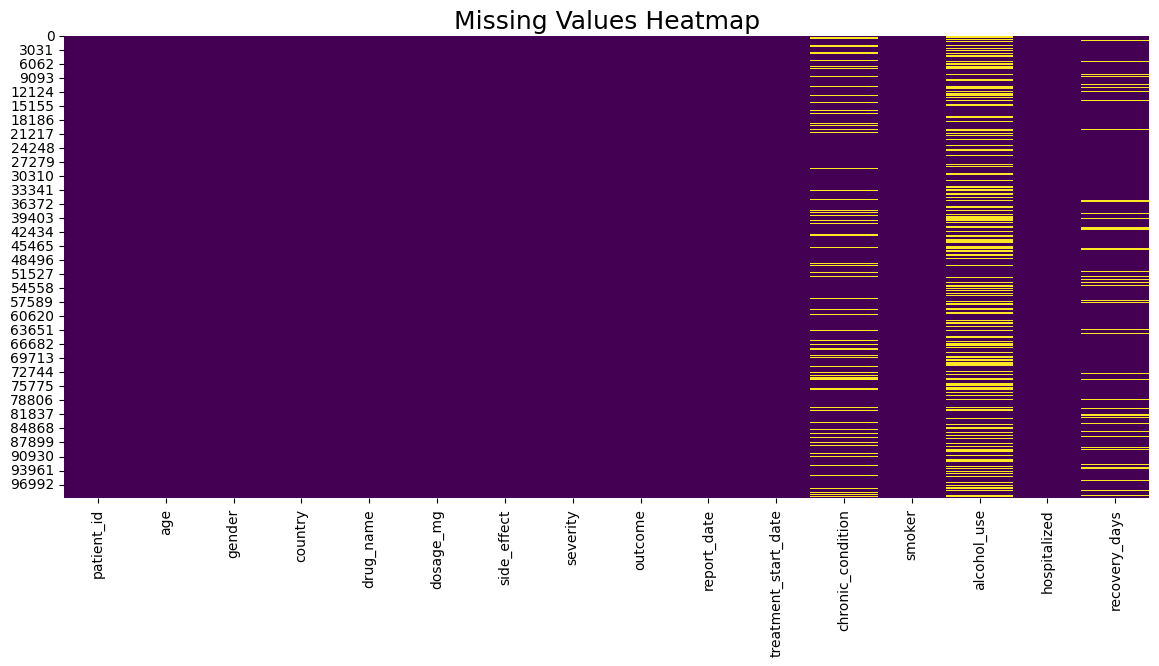

In [14]:
plt.figure(figsize=(14,6))

sns.heatmap(
    sk.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap", fontsize=18)
plt.show()

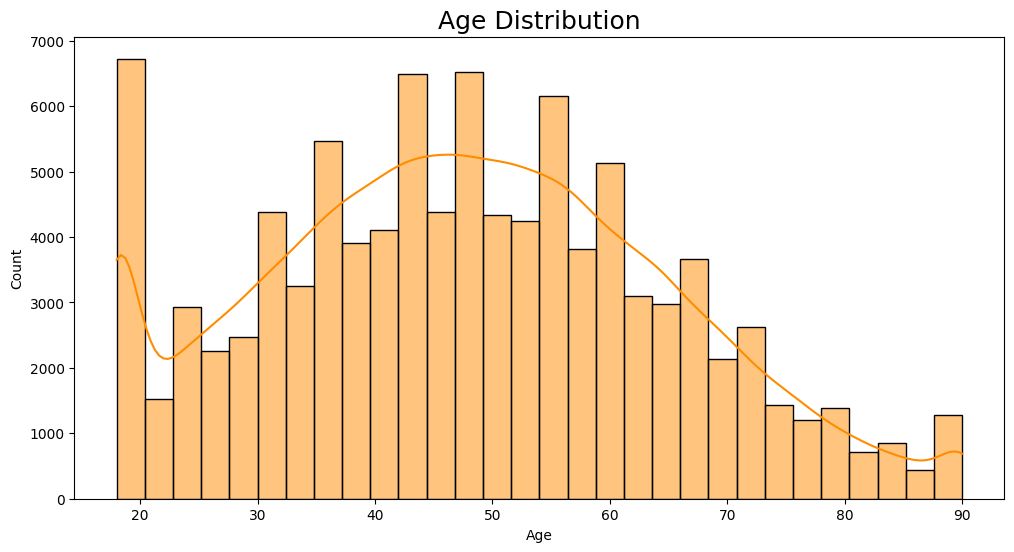

In [15]:
plt.figure(figsize=(12,6))

sns.histplot(
   sk['age'],
    bins=30,
    kde=True,
    color='darkorange'
)

plt.title("Age Distribution", fontsize=18)
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

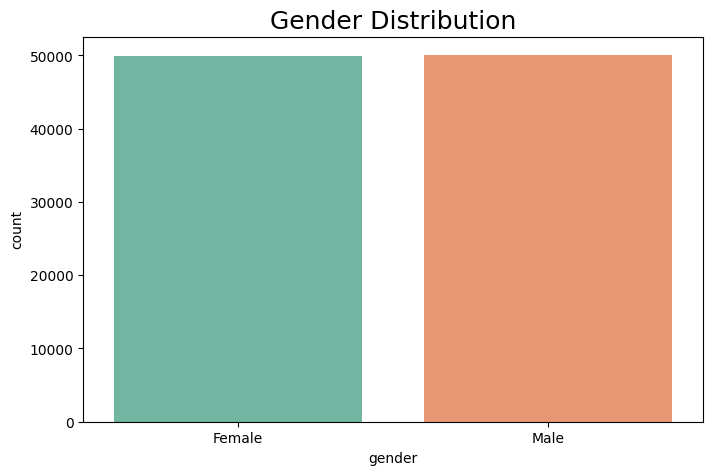

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='gender',
    data=sk,
    palette='Set2'
)

plt.title("Gender Distribution", fontsize=18)

plt.show()

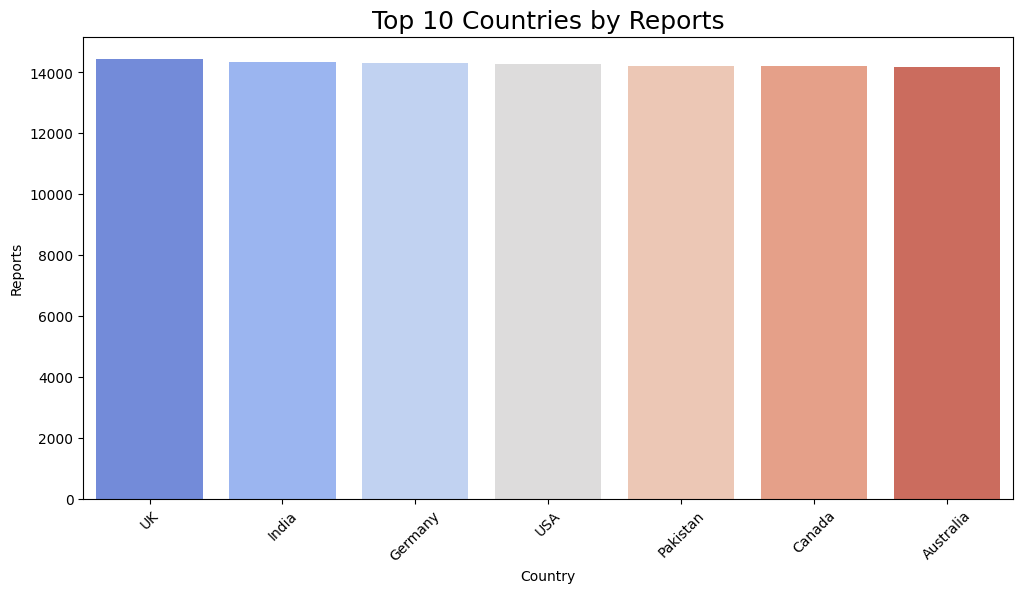

In [17]:
country_counts = sk['country'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_counts.index,
    y=country_counts.values,
    palette='coolwarm'
)

plt.title("Top 10 Countries by Reports", fontsize=18)
plt.xlabel("Country")
plt.ylabel("Reports")

plt.xticks(rotation=45)

plt.show()


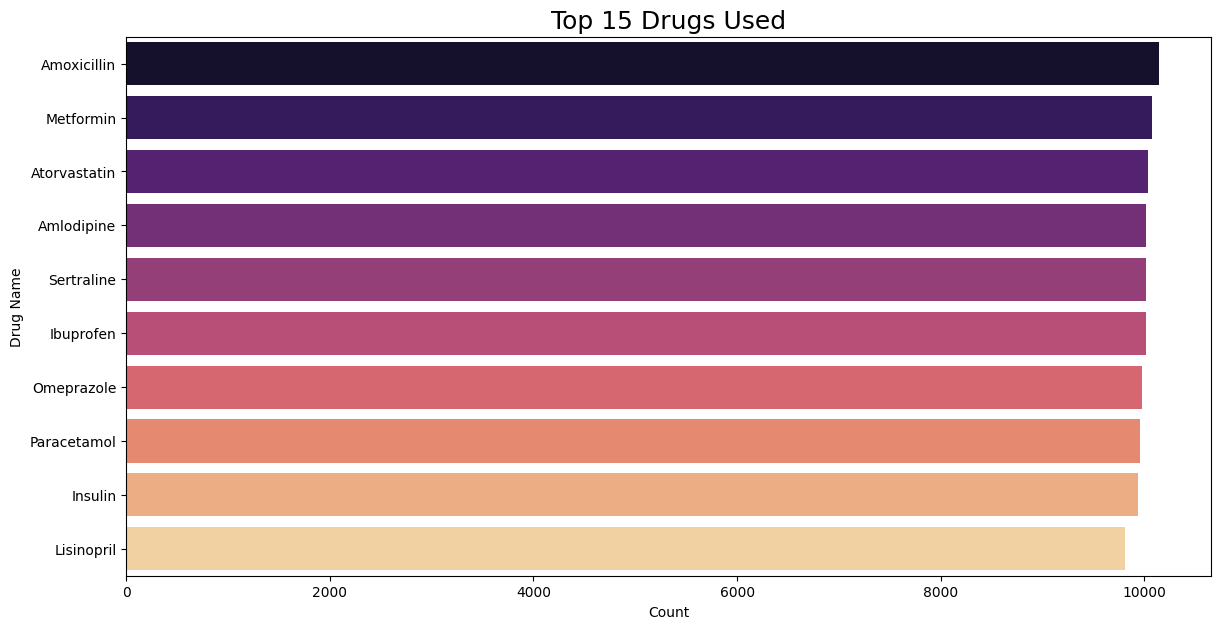

In [18]:
drug_counts = sk['drug_name'].value_counts().head(15)

plt.figure(figsize=(14,7))

sns.barplot(
    x=drug_counts.values,
    y=drug_counts.index,
    palette='magma'
)

plt.title("Top 15 Drugs Used", fontsize=18)
plt.xlabel("Count")
plt.ylabel("Drug Name")

plt.show()

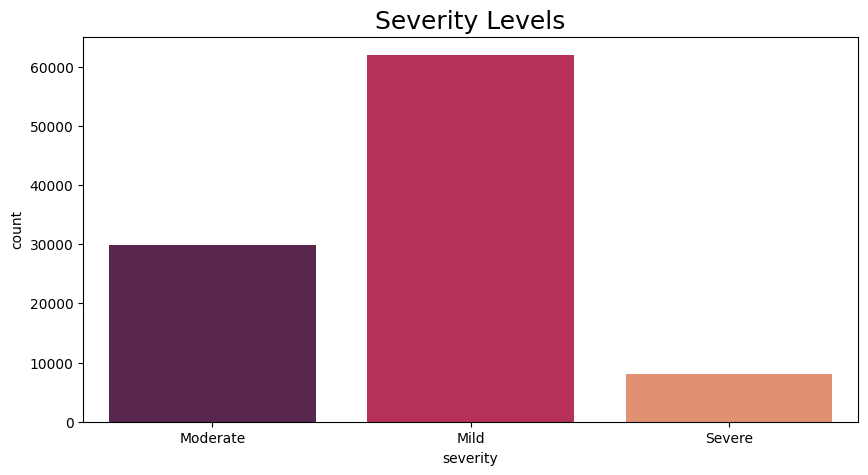

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='severity',
    data=sk,
    palette='rocket'
)

plt.title("Severity Levels", fontsize=18)

plt.show()

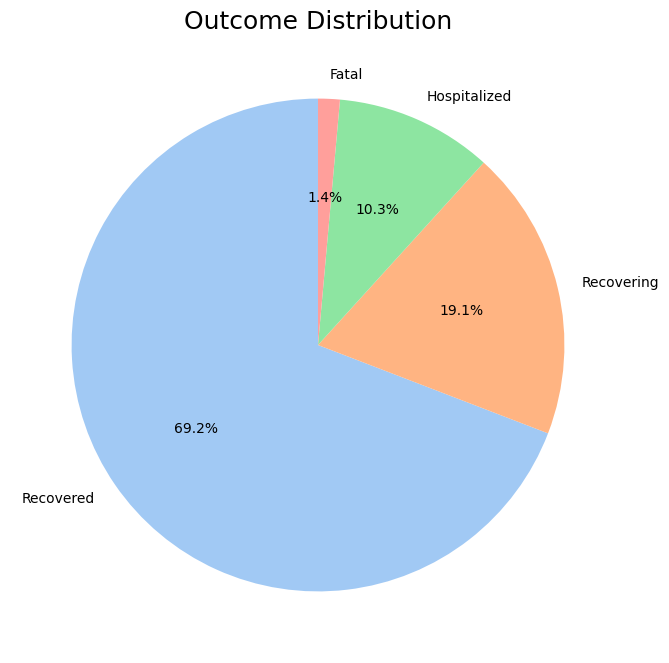

In [20]:
outcome_counts = sk['outcome'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    outcome_counts,
    labels=outcome_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=90
)

plt.title("Outcome Distribution", fontsize=18)

plt.show()

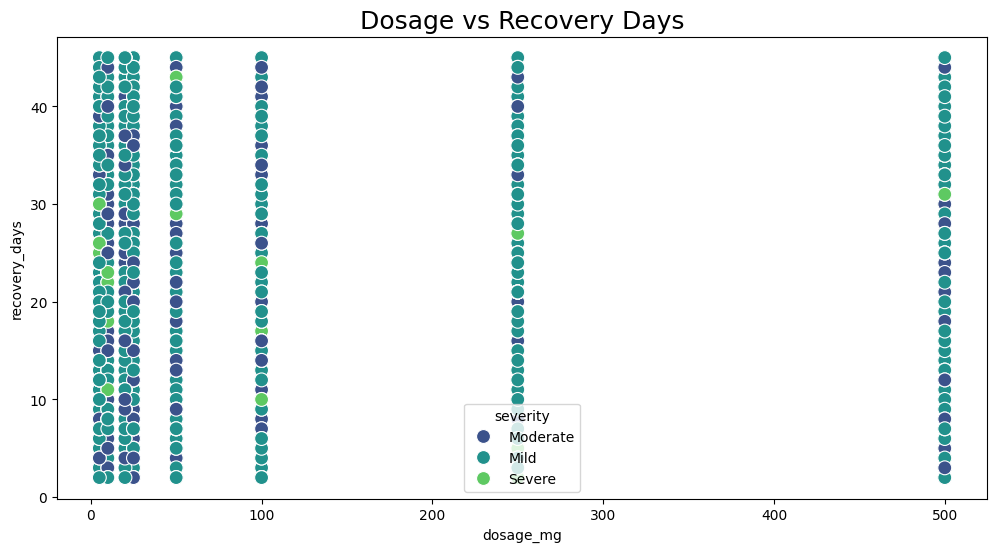

In [21]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x='dosage_mg',
    y='recovery_days',
    hue='severity',
    palette='viridis',
    data=sk,
    s=100
)

plt.title("Dosage vs Recovery Days", fontsize=18)

plt.show()


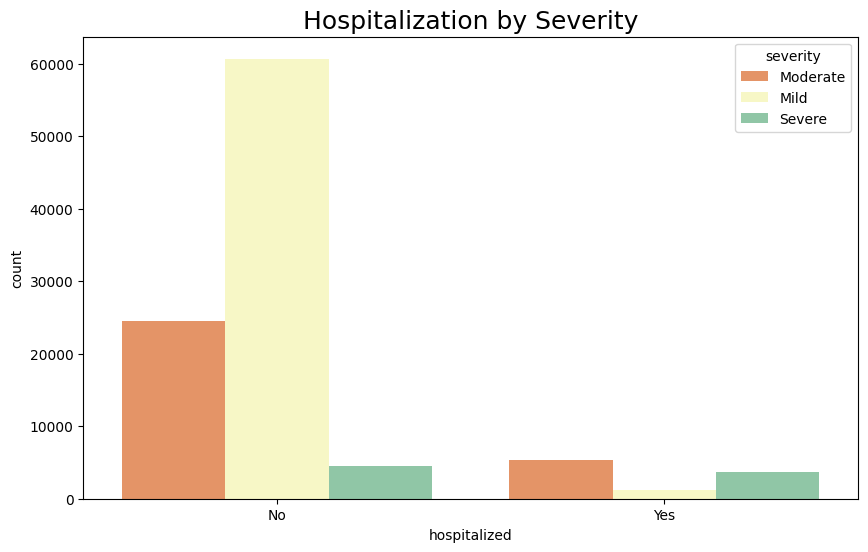

In [22]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='hospitalized',
    hue='severity',
    data=sk,
    palette='Spectral'
)

plt.title("Hospitalization by Severity", fontsize=18)

plt.show()


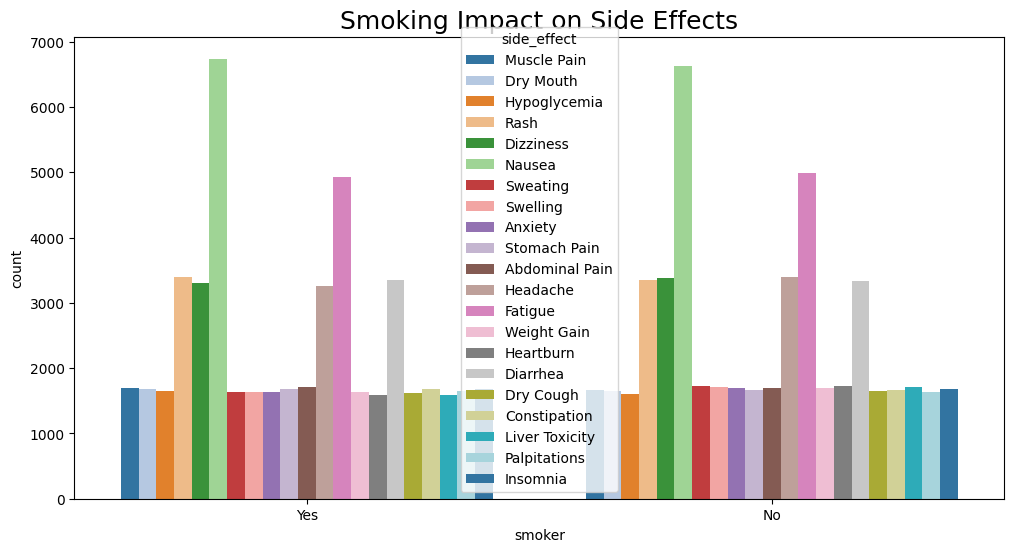

In [23]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='smoker',
    hue='side_effect',
    data=sk,
    palette='tab20'
)

plt.title("Smoking Impact on Side Effects", fontsize=18)

plt.show()

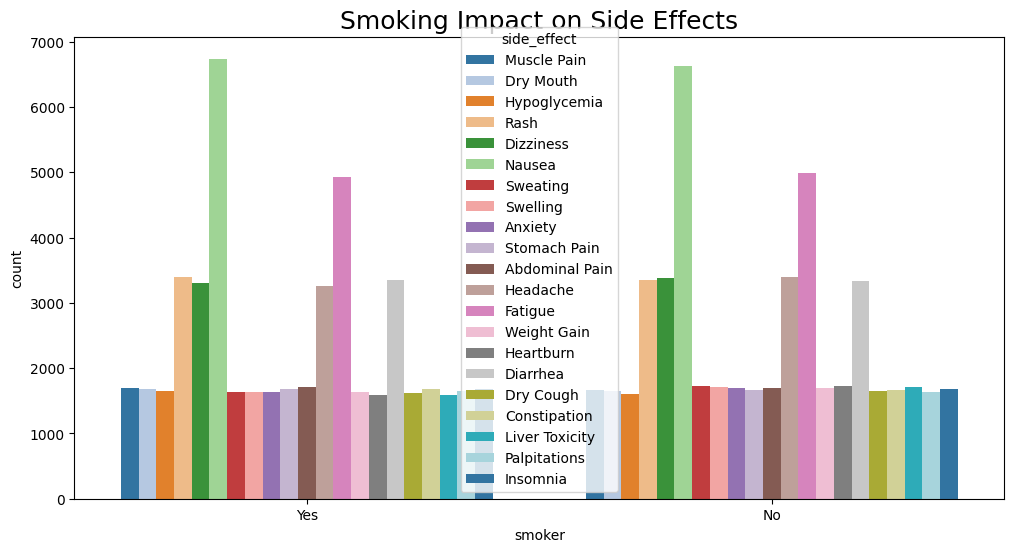

In [24]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='smoker',
    hue='side_effect',
    data=sk,
    palette='tab20'
)

plt.title("Smoking Impact on Side Effects", fontsize=18)

plt.show()

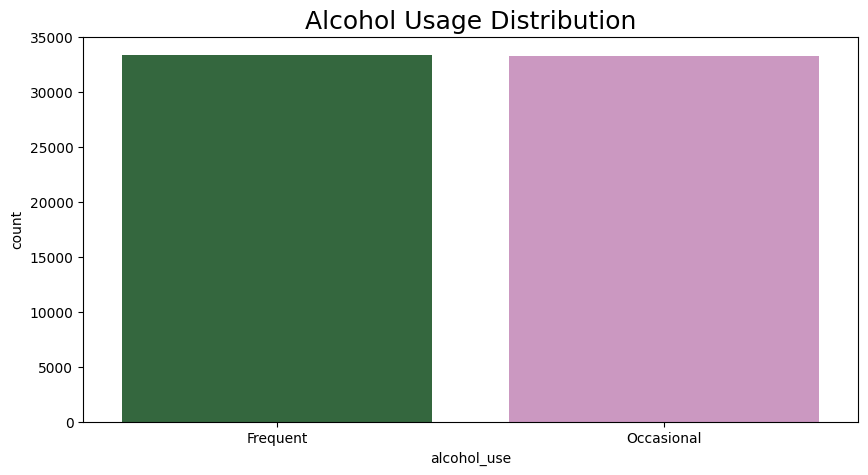

In [25]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='alcohol_use',
    data=sk,
    palette='cubehelix'
)

plt.title("Alcohol Usage Distribution", fontsize=18)

plt.show()

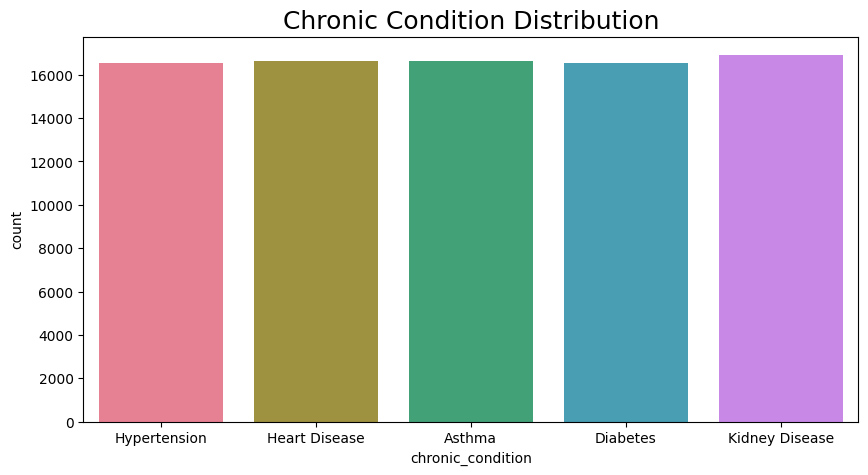

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='chronic_condition',
    data=sk,
    palette='husl'
)

plt.title("Chronic Condition Distribution", fontsize=18)

plt.show()

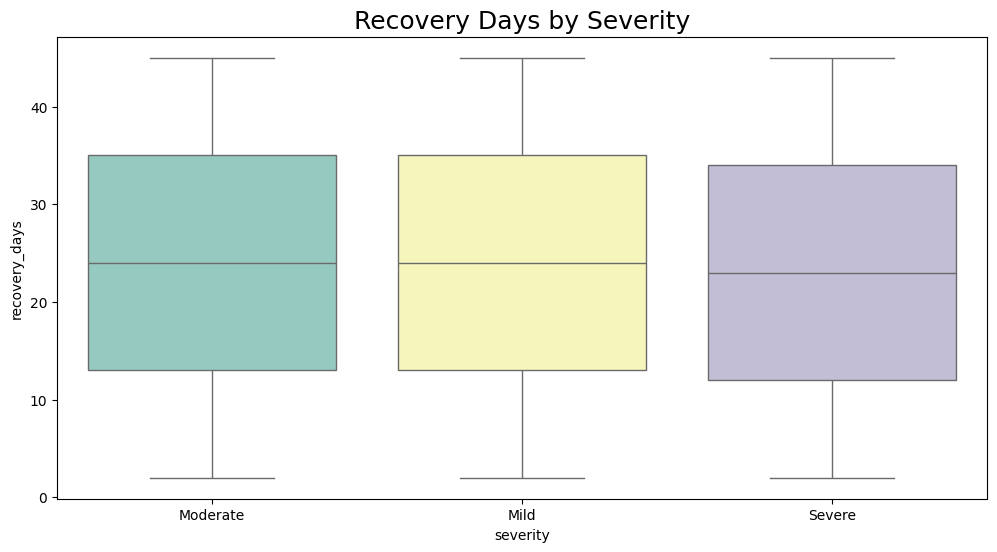

In [27]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='severity',
    y='recovery_days',
    data=sk,
    palette='Set3'
)

plt.title("Recovery Days by Severity", fontsize=18)

plt.show()


In [28]:
fig = px.scatter(
    sk,
    x='dosage_mg',
    y='recovery_days',
    color='severity',
    size='age',
    hover_data=['drug_name', 'country'],
    color_discrete_sequence=px.colors.qualitative.Bold,
    title='Interactive Dosage vs Recovery Analysis'
)

fig.show()

In [29]:
fig = px.sunburst(
    sk,
    path=['country', 'drug_name', 'severity'],
    title='Country → Drug → Severity Analysis',
    color='recovery_days',
    color_continuous_scale='RdYlGn'
)

fig.show()

In [30]:
fig = px.treemap(
    sk,
    path=['drug_name', 'side_effect'],
    values='dosage_mg',
    color='recovery_days',
    color_continuous_scale='Turbo',
    title='Drug & Side Effects Treemap'
)

fig.show()

In [31]:
fig = px.scatter_3d(
    sk,
    x='age',
    y='dosage_mg',
    z='recovery_days',
    color='severity',
    size='dosage_mg',
    hover_data=['drug_name'],
    title='3D Patient Analysis'
)

fig.show()

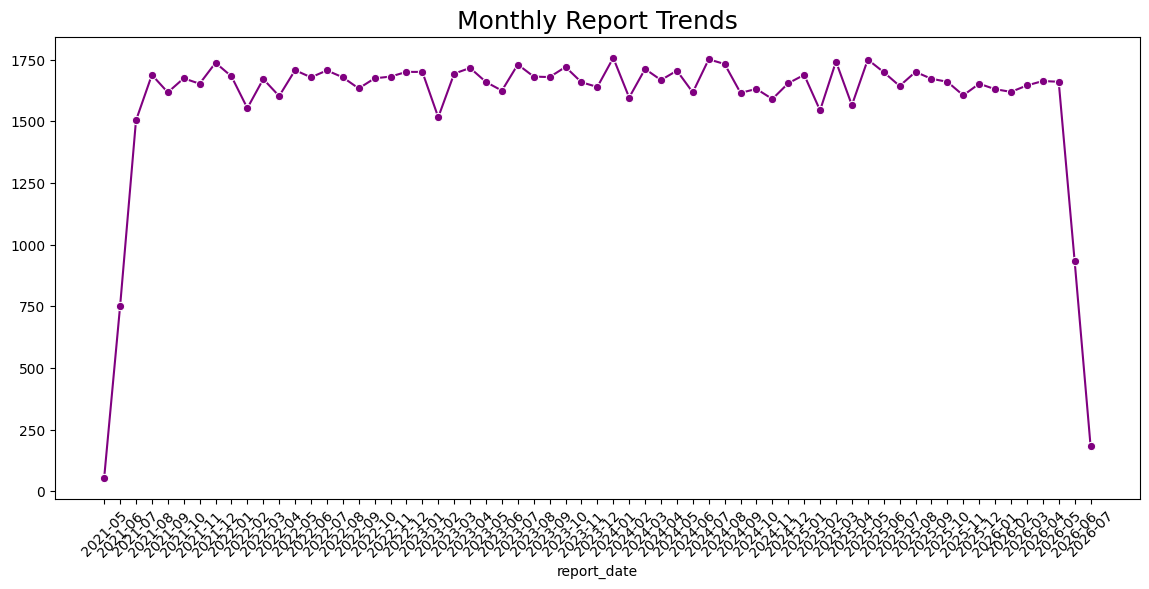

In [32]:
sk['report_date'] = pd.to_datetime(sk['report_date'])

monthly_reports = sk.groupby(
    sk['report_date'].dt.to_period('M')
).size()

monthly_reports.index = monthly_reports.index.astype(str)

plt.figure(figsize=(14,6))

sns.lineplot(
    x=monthly_reports.index,
    y=monthly_reports.values,
    marker='o',
    color='purple'
)

plt.title("Monthly Report Trends", fontsize=18)

plt.xticks(rotation=45)

plt.show()

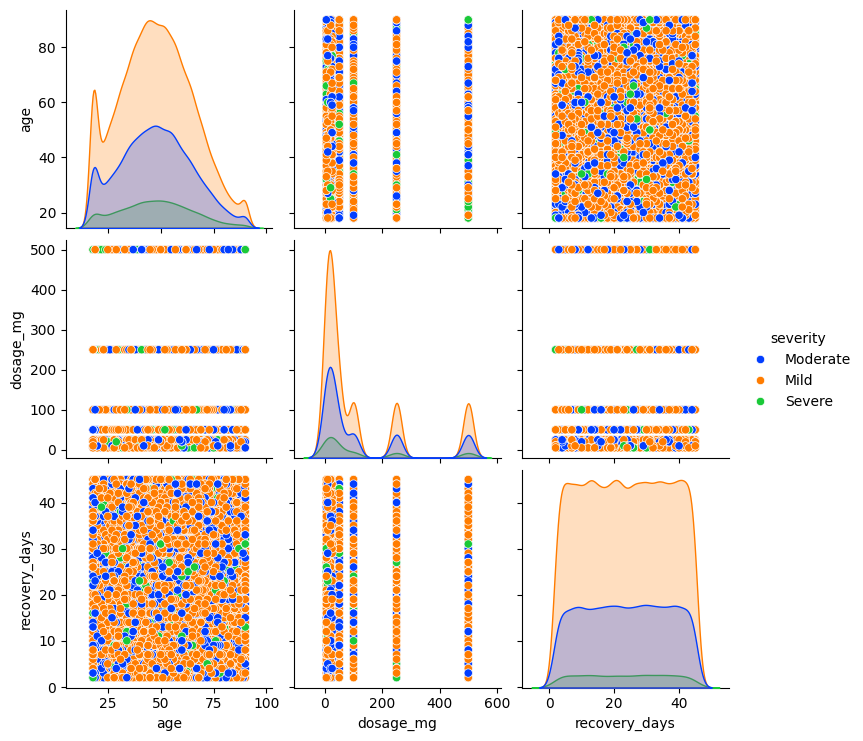

In [33]:

sns.pairplot(
    sk,
    hue='severity',
    palette='bright'
)

plt.show()

In [34]:
fig = px.scatter_matrix(
    sk,
    dimensions=['age', 'dosage_mg', 'recovery_days'],
    color='severity',
    title='Scatter Matrix Analysis'
)

fig.show()

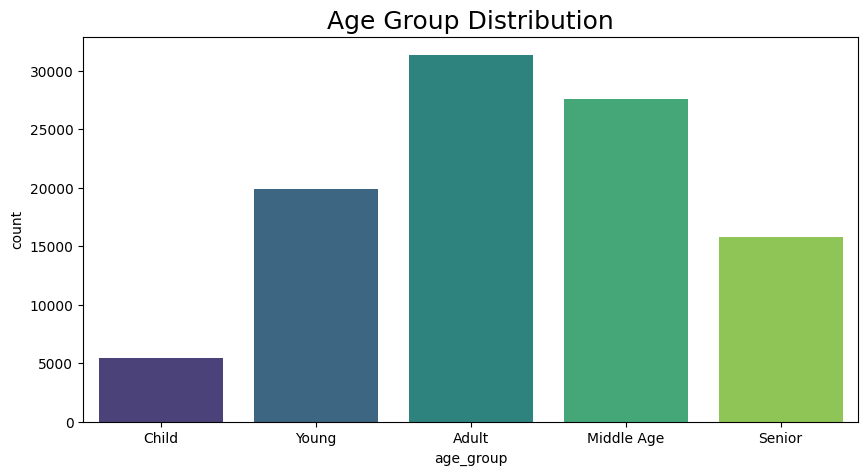

In [35]:
sk['age_group'] = pd.cut(
    sk['age'],
    bins=[0,18,35,50,65,100],
    labels=['Child','Young','Adult','Middle Age','Senior']
)

plt.figure(figsize=(10,5))

sns.countplot(
    x='age_group',
    data=sk,
    palette='viridis'
)

plt.title("Age Group Distribution", fontsize=18)

plt.show()

#### Data visualziation is completed

## Feature engineering

## using this columns apply target apply train test splitting label encoding apply ml algorithms in detail type code and dont leak data and apply roc curve and show accuracy in detail type code

In [36]:
# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


In [37]:
# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [38]:
data = sk.copy()

In [39]:
target = 'outcome'


In [40]:
data = data.drop(
    columns=[
        'patient_id',
        'report_date',
        'treatment_start_date'
    ],
    errors='ignore'
)


In [41]:
# Numerical columns
num_cols = data.select_dtypes(include=np.number).columns

for col in num_cols:

    data[col].fillna(
        data[col].median(),
        inplace=True
    )

# Categorical columns
cat_cols = data.select_dtypes(
    include=['object', 'category']
).columns

for col in cat_cols:

    data[col].fillna(
        data[col].mode()[0],
        inplace=True
    )


In [42]:
data['age_group'] = pd.cut(
    data['age'],
    bins=[0,18,35,50,65,100],
    labels=['Child','Young','Adult','Middle Age','Senior']
)

In [43]:
label_encoders = {}

categorical_cols = data.select_dtypes(
    include=['object', 'category']
).columns

for col in categorical_cols:

    le = LabelEncoder()

    data[col] = le.fit_transform(
        data[col].astype(str)
    )

    label_encoders[col] = le


In [44]:
target = 'outcome'

In [45]:
X = data.drop(target, axis=1)

y = data[target]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape : (80000, 13)
Testing Shape : (20000, 13)


In [47]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [48]:
models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True
    )
}


In [49]:
results = []

In [50]:
plt.figure(figsize=(10,8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>



MODEL : Logistic Regression

Accuracy : 0.8092

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       285
           1       1.00      1.00      1.00      2063
           2       0.80      0.98      0.88     13833
           3       0.56      0.14      0.22      3819

    accuracy                           0.81     20000
   macro avg       0.59      0.53      0.53     20000
weighted avg       0.76      0.81      0.76     20000



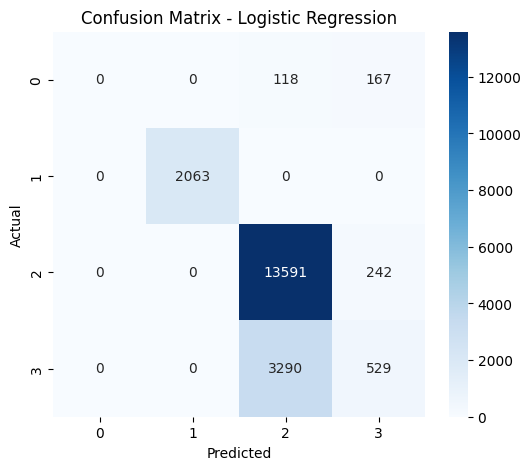



MODEL : Decision Tree

Accuracy : 0.8205

Classification Report

              precision    recall  f1-score   support

           0       0.71      1.00      0.83       285
           1       1.00      1.00      1.00      2063
           2       0.81      0.98      0.88     13833
           3       0.69      0.14      0.23      3819

    accuracy                           0.82     20000
   macro avg       0.80      0.78      0.74     20000
weighted avg       0.80      0.82      0.77     20000



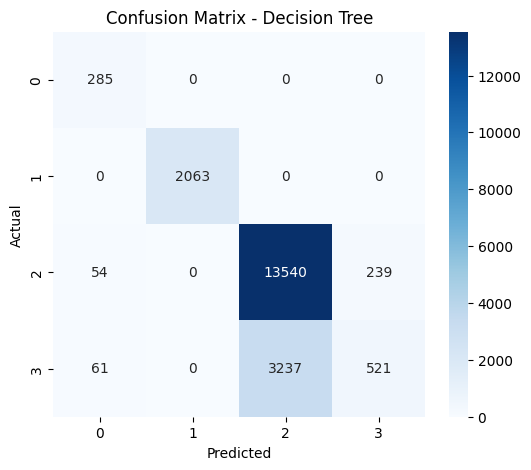



MODEL : Random Forest

Accuracy : 0.8079

Classification Report

              precision    recall  f1-score   support

           0       0.77      0.89      0.83       285
           1       1.00      1.00      1.00      2063
           2       0.82      0.93      0.87     13833
           3       0.51      0.26      0.34      3819

    accuracy                           0.81     20000
   macro avg       0.77      0.77      0.76     20000
weighted avg       0.78      0.81      0.78     20000



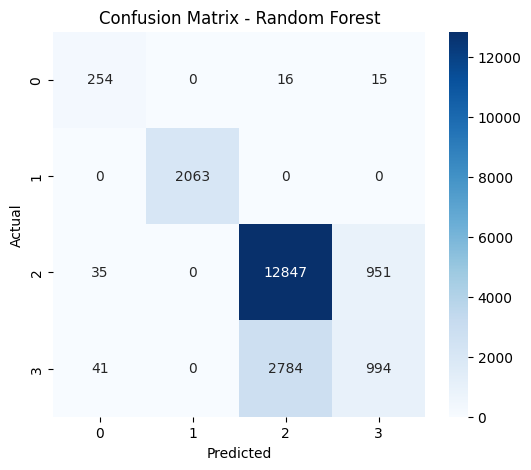



MODEL : Gradient Boosting

Accuracy : 0.8203

Classification Report

              precision    recall  f1-score   support

           0       0.72      0.99      0.83       285
           1       1.00      1.00      1.00      2063
           2       0.81      0.98      0.88     13833
           3       0.68      0.14      0.23      3819

    accuracy                           0.82     20000
   macro avg       0.80      0.78      0.74     20000
weighted avg       0.80      0.82      0.77     20000



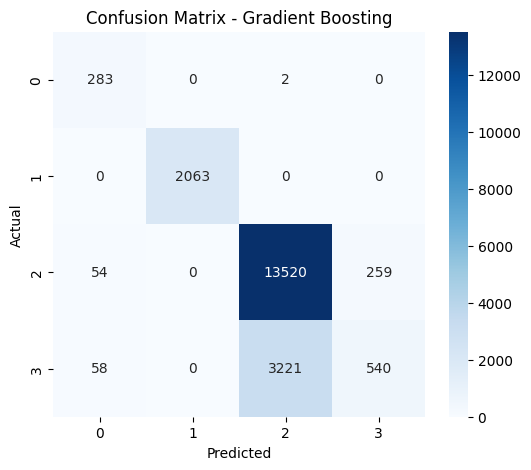



MODEL : KNN

Accuracy : 0.7867

Classification Report

              precision    recall  f1-score   support

           0       0.31      0.27      0.29       285
           1       1.00      1.00      1.00      2063
           2       0.82      0.91      0.86     13833
           3       0.44      0.28      0.34      3819

    accuracy                           0.79     20000
   macro avg       0.64      0.61      0.62     20000
weighted avg       0.76      0.79      0.77     20000



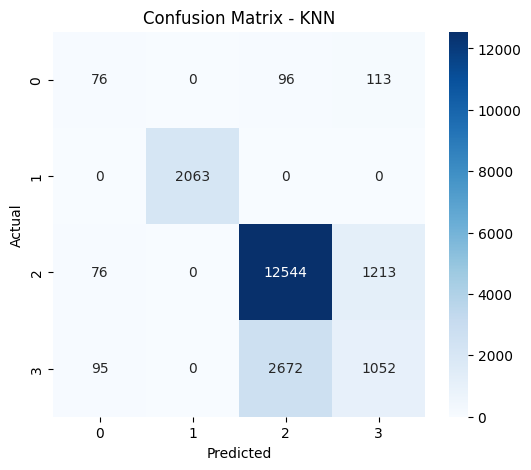



MODEL : SVM

Accuracy : 0.8092

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       285
           1       1.00      1.00      1.00      2063
           2       0.80      0.98      0.88     13833
           3       0.56      0.14      0.22      3819

    accuracy                           0.81     20000
   macro avg       0.59      0.53      0.53     20000
weighted avg       0.76      0.81      0.76     20000



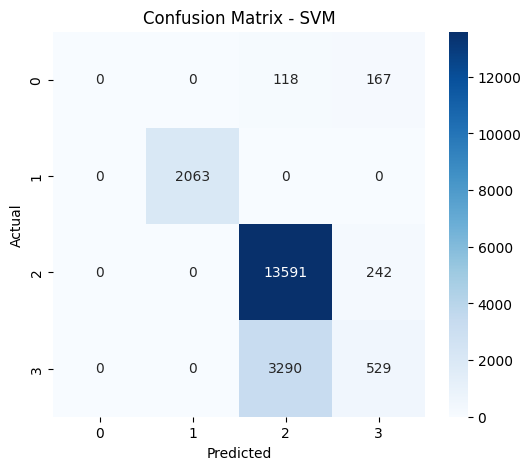



FINAL MODEL COMPARISON
                 Model  Accuracy          AUC
1        Decision Tree   0.82045  Multi-Class
3    Gradient Boosting   0.82030  Multi-Class
0  Logistic Regression   0.80915  Multi-Class
5                  SVM   0.80915  Multi-Class
2        Random Forest   0.80790  Multi-Class
4                  KNN   0.78675  Multi-Class

Best Model : Decision Tree

Top Important Features

              Feature  Importance
10       hospitalized    0.247932
11      recovery_days    0.158509
6            severity    0.155417
0                 age    0.099030
5         side_effect    0.064318
4           dosage_mg    0.060896
2             country    0.055301
3           drug_name    0.047819
7   chronic_condition    0.040861
12          age_group    0.020721


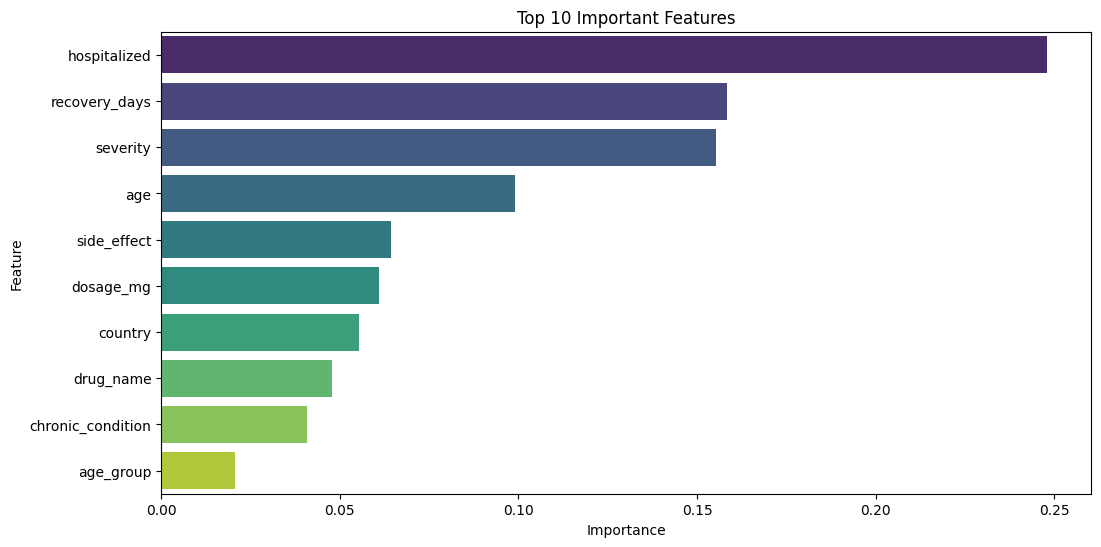

In [51]:
for name, model in models.items():

    print("\n")
    print("="*60)
    print(f"MODEL : {name}")
    print("="*60)

    

    model.fit(X_train_scaled, y_train)

    

    y_pred = model.predict(X_test_scaled)

   
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy : {accuracy:.4f}")

    

    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))


    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {name}')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

   

    # Only for binary classification

    if len(np.unique(y)) == 2:

        y_prob = model.predict_proba(
            X_test_scaled
        )[:,1]

        fpr, tpr, thresholds = roc_curve(
            y_test,
            y_prob
        )

        auc_score = roc_auc_score(
            y_test,
            y_prob
        )

        plt.plot(
            fpr,
            tpr,
            label=f'{name} (AUC = {auc_score:.3f})'
        )

        results.append([
            name,
            accuracy,
            auc_score
        ])

    else:

        results.append([
            name,
            accuracy,
            "Multi-Class"
        ])



if len(np.unique(y)) == 2:

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve Comparison")

    plt.legend()

    plt.show()


results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'AUC'
    ]
)

print("\n")
print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

print(
    results_df.sort_values(
        by='Accuracy',
        ascending=False
    )
)



best_model_name = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]['Model']

print("\nBest Model :", best_model_name)



rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features\n")

print(importance.head(10))


plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10),
    palette='viridis'
)

plt.title("Top 10 Important Features")

plt.show()